<a href="https://colab.research.google.com/github/Iditc/log-anomaly-detection/blob/main/notebooks/08_deeplog_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## deeplog LSTM

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Imports and paths
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path('/content/drive/MyDrive/log-anomaly-detection')
DATA_PROC = BASE / 'data' / 'processed'
RESULTS = BASE / 'results'

In [3]:
# Load full parsed data — we need the sequence of template IDs per block
df = pd.read_parquet(DATA_PROC / "hdfs_full_parsed.parquet")
print(f"Shape: {df.shape}")

Shape: (11175629, 4)


Now we build the template sequences per block. This code groups log lines by block_id and creates an ordered list of template IDs for each block

In [4]:
# Build sequence of template IDs per block (in order of appearance)
print("Building sequences...")
sequences = df.groupby("block_id").agg(
    template_seq=("template_id", list),
    label=("Label", "first")
).reset_index()

print(f"Total blocks: {len(sequences):,}")
print(f"\nExample sequence (first block):")
print(f"  Block: {sequences.iloc[0]['block_id']}")
print(f"  Label: {sequences.iloc[0]['label']}")
print(f"  Sequence: {sequences.iloc[0]['template_seq']}")
print(f"  Length: {len(sequences.iloc[0]['template_seq'])}")

Building sequences...
Total blocks: 575,061

Example sequence (first block):
  Block: blk_-1000002529962039464
  Label: Normal
  Sequence: [1, 1, 1, 48, 49, 4, 49, 4, 5, 5, 5, 49, 4]
  Length: 13


Now we can see the actual sequence — template 1 three times, then 48, 49, 4, etc.

DeepLog's idea: train an LSTM to predict the next template given the previous ones. If the actual next template is "unexpected" (low probability), flag it as anomaly.

Sequence lengths

In [5]:
# Check sequence length distribution
seq_lengths = sequences["template_seq"].apply(len)

print("Sequence length stats:")
print(seq_lengths.describe())
print(f"\nNormal blocks avg length: {seq_lengths[sequences['label'] == 'Normal'].mean():.1f}")
print(f"Anomaly blocks avg length: {seq_lengths[sequences['label'] == 'Anomaly'].mean():.1f}")

Sequence length stats:
count    575061.000000
mean         19.433815
std           5.177735
min           2.000000
25%          19.000000
50%          19.000000
75%          20.000000
max         298.000000
Name: template_seq, dtype: float64

Normal blocks avg length: 19.5
Anomaly blocks avg length: 17.1


In [6]:
# Create sliding window sequences for LSTM
# Input: [t1, t2, t3, ...] → pairs of (window, next_template)
# Example with window=3: [1,4,5,17] → ([1,4,5], 17), ([4,5,17], next)

window_size = 5

# Train only on normal blocks (DeepLog learns "normal" behavior)
normal_seqs = sequences[sequences["label"] == "Normal"]["template_seq"].values

print(f"Normal blocks: {len(normal_seqs):,}")

X_windows = []
y_next = []

for seq in normal_seqs:
    if len(seq) <= window_size:
        continue
    for i in range(len(seq) - window_size):
        X_windows.append(seq[i:i + window_size])
        y_next.append(seq[i + window_size])

X_windows = np.array(X_windows)
y_next = np.array(y_next)

print(f"Training windows: {len(X_windows):,}")
print(f"Unique next templates: {len(np.unique(y_next))}")
print(f"\nExample: input {X_windows[0]} → next {y_next[0]}")

Normal blocks: 558,223
Training windows: 8,096,264
Unique next templates: 27

Example: input [ 1  1  1 48 49] → next 4


Build the PyTorch LSTM model

In [7]:
# Install and import PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
# Define DeepLog LSTM model
class DeepLog(nn.Module):
    def __init__(self, num_templates, hidden_size=64, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(num_templates + 1, 32)
        self.lstm = nn.LSTM(32, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_templates + 1)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

num_templates = int(max(y_next.max(), X_windows.max())) + 1
model = DeepLog(num_templates).to(device)
print(f"Model created. Templates: {num_templates}")
print(model)

Model created. Templates: 51
DeepLog(
  (embedding): Embedding(52, 32)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=52, bias=True)
)


Prep the data as PyTorch tensors and train the model

In [9]:
# Prepare PyTorch DataLoader
X_tensor = torch.LongTensor(X_windows).to(device)
y_tensor = torch.LongTensor(y_next).to(device)

dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=4096, shuffle=True)

print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 1977


In [10]:
# Train DeepLog
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f}")

print("Training complete.")

Epoch 1/5 — Loss: 0.4424
Epoch 2/5 — Loss: 0.2987
Epoch 3/5 — Loss: 0.2948
Epoch 4/5 — Loss: 0.2930
Epoch 5/5 — Loss: 0.2919
Training complete.


In [11]:
# Anomaly detection: check how many "unexpected" steps each block has
def detect_anomaly(seq, model, window_size, top_k=5, threshold=0.3):
    """Returns True if block is anomaly.
    For each step, check if actual next template is in top-K predictions.
    If more than threshold% of steps are unexpected → anomaly."""
    if len(seq) <= window_size:
        return True

    model.eval()
    unexpected = 0
    total = 0

    with torch.no_grad():
        for i in range(len(seq) - window_size):
            window = torch.LongTensor([seq[i:i + window_size]]).to(device)
            output = model(window)
            top_k_preds = torch.topk(output, top_k).indices[0].cpu().numpy()
            actual = seq[i + window_size]
            if actual not in top_k_preds:
                unexpected += 1
            total += 1

    return (unexpected / total) > threshold

# Test on a few examples
normal_example = sequences[sequences["label"] == "Normal"].iloc[0]
anomaly_example = sequences[sequences["label"] == "Anomaly"].iloc[0]

print(f"Normal block: anomaly={detect_anomaly(normal_example['template_seq'], model, window_size)}")
print(f"Anomaly block: anomaly={detect_anomaly(anomaly_example['template_seq'], model, window_size)}")

Normal block: anomaly=False
Anomaly block: anomaly=True


In [12]:
# Fix: rebuild model with enough templates for ALL blocks (not just normal)
all_template_ids = df["template_id"].max() + 1
print(f"Max template ID in full data: {all_template_ids}")

# Recreate model with correct size
model = DeepLog(all_template_ids).to(device)

# Retrain
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f}")

print("Training complete.")

Max template ID in full data: 56
Epoch 1/5 — Loss: 0.4462
Epoch 2/5 — Loss: 0.2971
Epoch 3/5 — Loss: 0.2938
Epoch 4/5 — Loss: 0.2924
Epoch 5/5 — Loss: 0.2915
Training complete.


In [13]:
# Use max template ID from ALL blocks (not just normal)
num_templates = int(df["template_id"].max()) + 1
model = DeepLog(num_templates).to(device)
print(f"Model created. Templates: {num_templates}")

Model created. Templates: 56


Now let's evaluate. But instead of checking one block at a time (slow), let's batch the predictions

In [14]:
# Evaluate all blocks — batched for speed
print("Evaluating all blocks...")
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for i, row in sequences.iterrows():
        seq = row["template_seq"]
        label = 1 if row["label"] == "Anomaly" else 0

        if len(seq) <= window_size:
            y_true.append(label)
            y_pred.append(1)
            continue

        # Build all windows for this block at once
        windows = []
        actuals = []
        for j in range(len(seq) - window_size):
            windows.append(seq[j:j + window_size])
            actuals.append(seq[j + window_size])

        windows_tensor = torch.LongTensor(windows).to(device)
        output = model(windows_tensor)
        top_k_preds = torch.topk(output, 5).indices.cpu().numpy()

        unexpected = sum(1 for k, actual in enumerate(actuals) if actual not in top_k_preds[k])
        is_anomaly = (unexpected / len(actuals)) > 0.3

        y_true.append(label)
        y_pred.append(1 if is_anomaly else 0)

        if (i + 1) % 50000 == 0:
            print(f"  Processed {i+1:,} / {len(sequences):,} blocks...")

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("Done!")

Evaluating all blocks...
  Processed 50,000 / 575,061 blocks...
  Processed 100,000 / 575,061 blocks...
  Processed 200,000 / 575,061 blocks...
  Processed 250,000 / 575,061 blocks...
  Processed 300,000 / 575,061 blocks...
  Processed 350,000 / 575,061 blocks...
  Processed 400,000 / 575,061 blocks...
  Processed 450,000 / 575,061 blocks...
  Processed 500,000 / 575,061 blocks...
Done!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00    558223
     Anomaly       0.03      1.00      0.06     16838

    accuracy                           0.03    575061
   macro avg       0.01      0.50      0.03    575061
weighted avg       0.00      0.03      0.00    575061



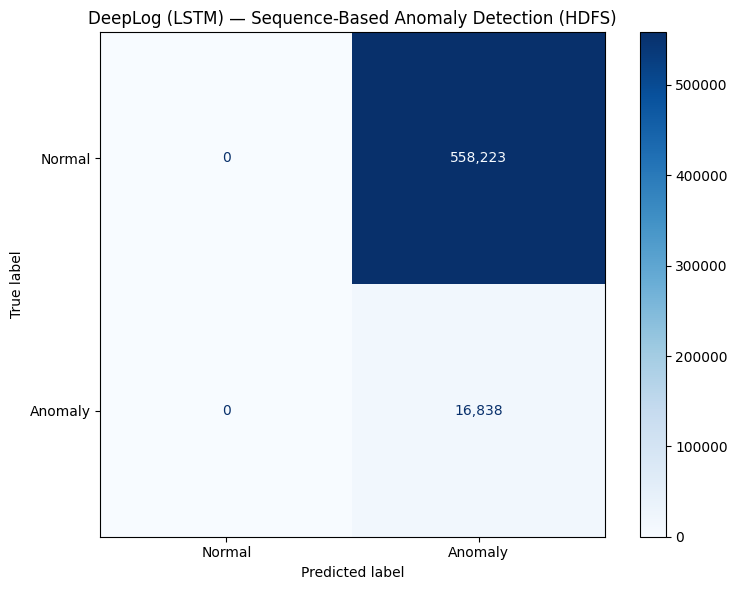

In [15]:
# Evaluate DeepLog results
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))

# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("DeepLog (LSTM) — Sequence-Based Anomaly Detection (HDFS)")
plt.tight_layout()
plt.savefig(str(RESULTS / "deeplog_confusion_matrix.png"), dpi=150)
plt.show()

The model flagged almost everything as anomaly. The threshold is too aggressive.

Let's understand why — check the distribution of "unexpected ratio" across blocks

In [16]:
# Check the unexpected ratio distribution for normal vs anomaly blocks
print("Calculating unexpected ratios...")
model.eval()

ratios_normal = []
ratios_anomaly = []

with torch.no_grad():
    for i, row in sequences.iterrows():
        seq = row["template_seq"]
        if len(seq) <= window_size:
            continue

        windows = []
        actuals = []
        for j in range(len(seq) - window_size):
            windows.append(seq[j:j + window_size])
            actuals.append(seq[j + window_size])

        windows_tensor = torch.LongTensor(windows).to(device)
        output = model(windows_tensor)
        top_k_preds = torch.topk(output, 5).indices.cpu().numpy()

        unexpected = sum(1 for k, actual in enumerate(actuals) if actual not in top_k_preds[k])
        ratio = unexpected / len(actuals)

        if row["label"] == "Normal":
            ratios_normal.append(ratio)
        else:
            ratios_anomaly.append(ratio)

        if (i + 1) % 100000 == 0:
            print(f"  Processed {i+1:,}...")

print(f"\nNormal blocks unexpected ratio:")
print(f"  Mean: {np.mean(ratios_normal):.3f}")
print(f"  Median: {np.median(ratios_normal):.3f}")
print(f"  95th percentile: {np.percentile(ratios_normal, 95):.3f}")

print(f"\nAnomaly blocks unexpected ratio:")
print(f"  Mean: {np.mean(ratios_anomaly):.3f}")
print(f"  Median: {np.median(ratios_anomaly):.3f}")


Calculating unexpected ratios...
  Processed 100,000...
  Processed 200,000...
  Processed 300,000...
  Processed 400,000...
  Processed 500,000...

Normal blocks unexpected ratio:
  Mean: 0.958
  Median: 1.000
  95th percentile: 1.000

Anomaly blocks unexpected ratio:
  Mean: 0.966
  Median: 1.000


In [17]:
# Check model accuracy at different top_k values
print("Checking top_k accuracy on normal blocks (sample)...")
model.eval()

sample_normal = sequences[sequences["label"] == "Normal"].sample(10000, random_state=42)

for k in [5, 10, 15, 20, 30]:
    correct = 0
    total = 0
    with torch.no_grad():
        for _, row in sample_normal.iterrows():
            seq = row["template_seq"]
            if len(seq) <= window_size:
                continue
            windows = []
            actuals = []
            for j in range(len(seq) - window_size):
                windows.append(seq[j:j + window_size])
                actuals.append(seq[j + window_size])

            windows_tensor = torch.LongTensor(windows).to(device)
            output = model(windows_tensor)
            top_k_preds = torch.topk(output, k).indices.cpu().numpy()

            correct += sum(1 for idx, actual in enumerate(actuals) if actual in top_k_preds[idx])
            total += len(actuals)

    print(f"  top_k={k:2d}: accuracy {correct/total:.1%}")

Checking top_k accuracy on normal blocks (sample)...
  top_k= 5: accuracy 3.3%
  top_k=10: accuracy 7.0%
  top_k=15: accuracy 11.2%
  top_k=20: accuracy 16.2%
  top_k=30: accuracy 31.3%


In [18]:
# Check template ID distribution
all_ids = df["template_id"].unique()
print(f"Unique template IDs: {len(all_ids)}")
print(f"Min: {all_ids.min()}, Max: {all_ids.max()}")
print(f"Sorted: {sorted(all_ids)[:20]}...")


Unique template IDs: 55
Min: 1, Max: 55
Sorted: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]...


IDs are continuous 1-55, no gaps. That's not the problem.

The real issue is likely the model capacity and training. Let's try:

Bigger hidden size (128 instead of 64)
More epochs (20 instead of 5)
Larger embedding (64 instead of 32)

In [19]:
# Rebuild with larger model and train longer
model = DeepLog(num_templates=56, hidden_size=128, num_layers=2).to(device)

# Update the model class to use larger embedding
class DeepLog(nn.Module):
    def __init__(self, num_templates, hidden_size=128, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(num_templates + 1, 64)
        self.lstm = nn.LSTM(64, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, num_templates + 1)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = DeepLog(56).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train for 20 epochs
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f}")

print("Training complete.")


Epoch 5/20 — Loss: 0.2906
Epoch 10/20 — Loss: 0.2895
Epoch 15/20 — Loss: 0.2892
Epoch 20/20 — Loss: 0.2890
Training complete.


In [20]:
# New approach: supervised LSTM classifier
# Input: full template sequence → Output: Normal/Anomaly

class DeepLogClassifier(nn.Module):
    def __init__(self, num_templates, hidden_size=128, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(num_templates + 1, 64, padding_idx=0)
        self.lstm = nn.LSTM(64, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Pad all sequences to same length
from torch.nn.utils.rnn import pad_sequence

max_len = 50  # cap sequence length

def prepare_sequences(seqs, labels):
    X = []
    y = []
    for seq, label in zip(seqs, labels):
        seq = seq[:max_len]  # truncate long sequences
        padded = seq + [0] * (max_len - len(seq))  # pad short ones
        X.append(padded)
        y.append(1 if label == "Anomaly" else 0)
    return torch.LongTensor(X), torch.LongTensor(y)

# Split data
from sklearn.model_selection import train_test_split

train_seq, test_seq = train_test_split(sequences, test_size=0.2, random_state=42, stratify=sequences["label"])

X_train_seq, y_train_seq = prepare_sequences(train_seq["template_seq"].values, train_seq["label"].values)
X_test_seq, y_test_seq = prepare_sequences(test_seq["template_seq"].values, test_seq["label"].values)

print(f"Train: {len(X_train_seq):,} | Test: {len(X_test_seq):,}")

Train: 460,048 | Test: 115,013


In [21]:
# Train supervised LSTM classifier
train_dataset = TensorDataset(X_train_seq.to(device), y_train_seq.to(device))
train_loader_cls = DataLoader(train_dataset, batch_size=4096, shuffle=True)

model_cls = DeepLogClassifier(56).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cls.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    model_cls.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_cls:
        optimizer.zero_grad()
        output = model_cls(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader_cls)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f}")

print("Training complete.")

Epoch 1/10 — Loss: 0.1799
Epoch 2/10 — Loss: 0.1298
Epoch 3/10 — Loss: 0.1323
Epoch 4/10 — Loss: 0.1324
Epoch 5/10 — Loss: 0.1324
Epoch 6/10 — Loss: 0.1323
Epoch 7/10 — Loss: 0.1323
Epoch 8/10 — Loss: 0.1209
Epoch 9/10 — Loss: 0.1327
Epoch 10/10 — Loss: 0.1324
Training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99    111645
     Anomaly       0.00      0.00      0.00      3368

    accuracy                           0.97    115013
   macro avg       0.49      0.50      0.49    115013
weighted avg       0.94      0.97      0.96    115013



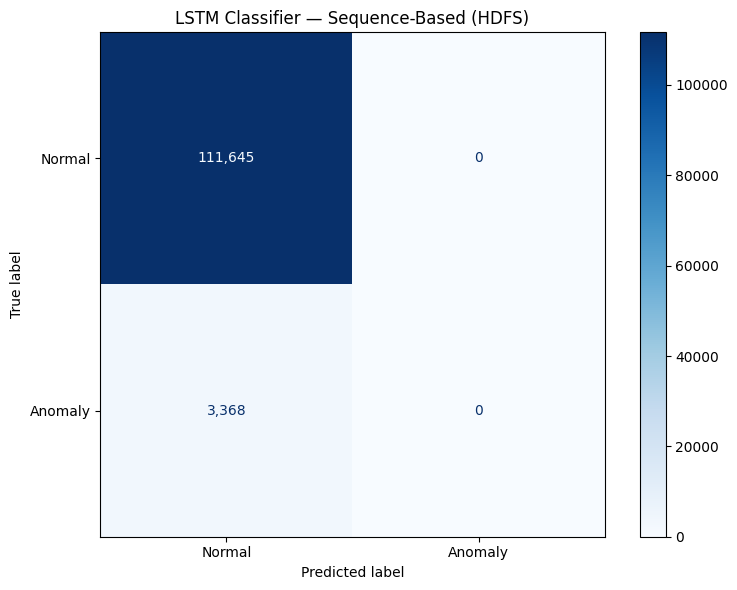

In [23]:
# Evaluate in batches to avoid memory issues
model_cls.eval()
y_pred_lstm = []

test_loader = DataLoader(TensorDataset(X_test_seq, y_test_seq), batch_size=4096, shuffle=False)

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        output = model_cls(batch_X.to(device))
        preds = output.argmax(dim=1).cpu().numpy()
        y_pred_lstm.extend(preds)

y_pred_lstm = np.array(y_pred_lstm)
y_test_np = y_test_seq.numpy()

print(classification_report(y_test_np, y_pred_lstm, target_names=["Normal", "Anomaly"]))

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred_lstm)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("LSTM Classifier — Sequence-Based (HDFS)")
plt.tight_layout()
plt.savefig(str(RESULTS / "lstm_classifier_confusion_matrix.png"), dpi=150)
plt.show()

In [24]:
# Fix class imbalance with weighted loss
from torch import tensor

# Weight anomaly class much higher
weights = tensor([1.0, (y_train_seq == 0).sum().item() / (y_train_seq == 1).sum().item()]).to(device)
print(f"Class weights: Normal={weights[0]:.1f}, Anomaly={weights[1]:.1f}")

model_cls = DeepLogClassifier(56).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model_cls.parameters(), lr=0.001)

num_epochs = 15
for epoch in range(num_epochs):
    model_cls.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_cls:
        optimizer.zero_grad()
        output = model_cls(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader_cls)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f}")

print("Training complete.")


Class weights: Normal=1.0, Anomaly=33.2
Epoch 5/15 — Loss: 0.6970
Epoch 10/15 — Loss: 0.6933
Epoch 15/15 — Loss: 0.6934
Training complete.


# Bad model, I'm moving on